=== SYMBOLIC ANALYSIS OF TOGGLE SWITCH ===

1. Defining symbolic variables and equations...
ODEs:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


2. Finding steady states numerically...

Found 3 unique steady state(s):
  Numeric steady state 1: u = 0.1010, v = 9.8990
  Numeric steady state 2: u = 2.0000, v = 2.0000
  Numeric steady state 3: u = 9.8990, v = 0.1010

4. Analyzing stability using the Jacobian matrix...
Jacobian matrix J = 


<IPython.core.display.Math object>


5. Evaluating Jacobian at each steady state...

--- Steady State 1: (u = 0.1010, v = 9.8990) ---
Jacobian at this state:
[[-1.        -0.0202041]
 [-1.9797959 -1.       ]]
Eigenvalues: -0.8000, -1.2000
Stability: STABLE (all eigenvalues negative)
Determinant: 0.9600, Trace: -2.0000
2D stability condition satisfied: det > 0 and trace < 0

--- Steady State 2: (u = 2.0000, v = 2.0000) ---
Jacobian at this state:
[[-1.  -1.6]
 [-1.6 -1. ]]
Eigenvalues: 0.6000, -2.6000
Stability: UNSTABLE (at least one positive eigenvalue)
Determinant: -1.5600, Trace: -2.0000

--- Steady State 3: (u = 9.8990, v = 0.1010) ---
Jacobian at this state:
[[-1.        -1.9797959]
 [-0.0202041 -1.       ]]
Eigenvalues: -0.8000, -1.2000
Stability: STABLE (all eigenvalues negative)
Determinant: 0.9600, Trace: -2.0000
2D stability condition satisfied: det > 0 and trace < 0

6. Visualizing steady states and their stability...


/var/folders/cs/lkcj7j890kv6kfxbkl56w9h80000gn/T/ipykernel_41591/1756542187.py:191: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[0].scatter(u_val, v_val, color=color, marker=marker, s=size,
/var/folders/cs/lkcj7j890kv6kfxbkl56w9h80000gn/T/ipykernel_41591/1756542187.py:237: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[1].scatter(u_val, v_val, color=color, marker=marker, s=100,


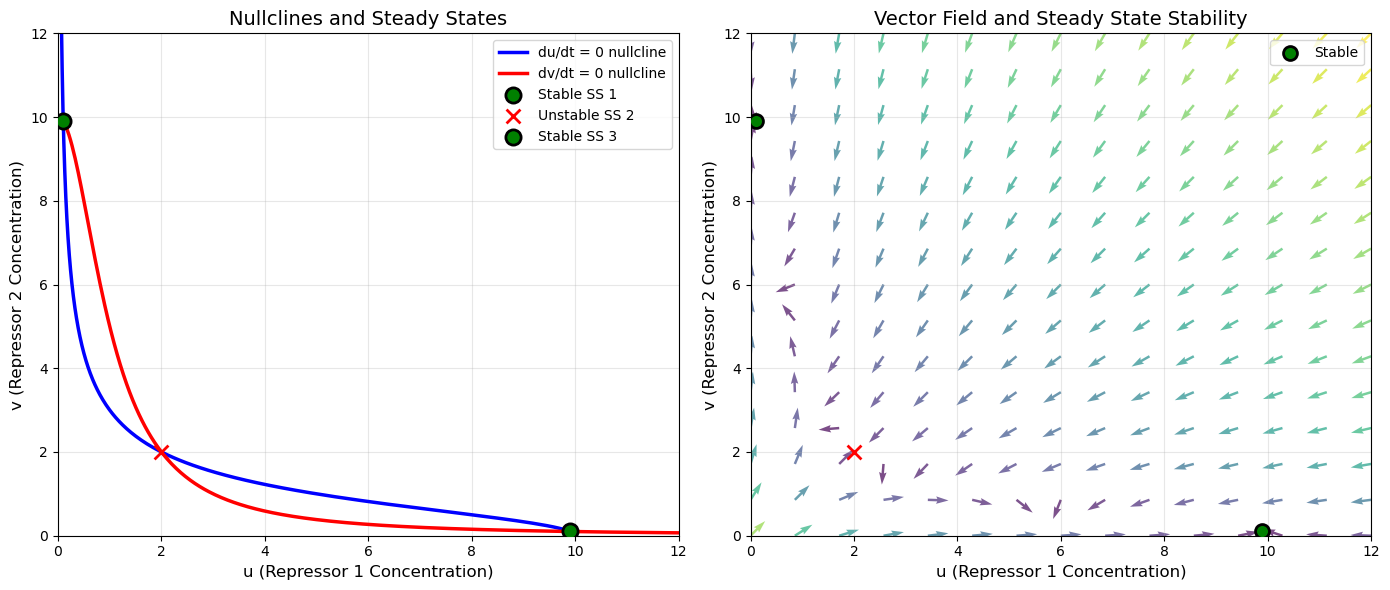

In [6]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, Math

# 1. SET UP SYMBOLIC VARIABLES AND EQUATIONS
print("=== SYMBOLIC ANALYSIS OF TOGGLE SWITCH ===")
print("\n1. Defining symbolic variables and equations...")

# Create symbolic variables
u, v = sp.symbols('u v', positive=True)  # concentrations must be positive
alpha1, alpha2, beta, gamma, n = sp.symbols('alpha1 alpha2 beta gamma n', positive=True)

# Define the ODEs
du_dt = alpha1/(1 + v**n) - beta*u
dv_dt = alpha2/(1 + u**n) - gamma*v

print(f"ODEs:")
display(Math(fr"\frac{{du}}{{dt}} = {sp.latex(du_dt)}"))
display(Math(fr"\frac{{dv}}{{dt}} = {sp.latex(dv_dt)}"))

# 2. FIND STEADY STATES NUMERICALLY
print("\n2. Finding steady states numerically...")

# Substitute parameters into the equations first
param_values = {
    alpha1: 10.0,
    alpha2: 10.0,
    beta: 1.0,
    gamma: 1.0,
    n: 2.0
}

du_dt_num = du_dt.subs(param_values)
dv_dt_num = dv_dt.subs(param_values)

# Define initial guesses to find the different bistable states
# (u_guess, v_guess)
guesses = [
    (0.5, 9.5),  # Guess for State 1 (Low u, High v)
    (2.0, 2.0),  # Guess for State 2 (Symmetric Unstable State u == v)
    (9.5, 0.5)   # Guess for State 3 (High u, Low v)
]


numeric_states = []
for guess in guesses:
    try:
        # nsolve finds the numerical root near the guess
        sol = sp.nsolve([du_dt_num, dv_dt_num], [u, v], guess)
        u_val = float(sol[0])
        v_val = float(sol[1])
        
        # Avoid adding duplicate states due to floating point variations
        if not any(np.allclose([u_val, v_val], s, atol=1e-4) for s in numeric_states):
            numeric_states.append((u_val, v_val))
    except Exception as e:
        print(f"Could not find root for guess {guess}: {e}")

print(f"\nFound {len(numeric_states)} unique steady state(s):")
for i, (u_val, v_val) in enumerate(numeric_states):
    print(f"  Numeric steady state {i+1}: u = {u_val:.4f}, v = {v_val:.4f}")
    
# # 2. FIND STEADY STATES BY SOLVING du/dt = 0 AND dv/dt = 0
# print("\n2. Finding steady states (solve du/dt = 0, dv/dt = 0)...")

# # Solve for steady states symbolically
# steady_states = sp.solve([du_dt, dv_dt], [u, v], dict=True)
# print(f"\nFound {len(steady_states)} steady state(s):")

# for i, sol in enumerate(steady_states):
#     print(f"\nSteady State {i+1}:")
#     display(Math(fr"u^* = {sp.latex(sol[u])}"))
#     display(Math(fr"v^* = {sp.latex(sol[v])}"))

# # 3. EVALUATE FOR SPECIFIC PARAMETERS (NUMERIC EXAMPLE)
# print("\n3. Evaluating for specific parameter values...")

# # Use the same parameters as our simulation
# param_values = {
#     alpha1: 10.0,
#     alpha2: 10.0,
#     beta: 1.0,
#     gamma: 1.0,
#     n: 2.0
# }

# print("Parameter values:")
# for param, value in param_values.items():
#     print(f"  {param} = {value}")

# # Calculate numeric steady states
# numeric_states = []
# for sol in steady_states:
#     u_val = float(sol[u].subs(param_values))
#     v_val = float(sol[v].subs(param_values))
#     numeric_states.append((u_val, v_val))
#     print(f"\nNumeric steady state: u = {u_val:.4f}, v = {v_val:.4f}")

# 4. ANALYZE STABILITY: CALCULATE THE JACOBIAN MATRIX
print("\n4. Analyzing stability using the Jacobian matrix...")

# Create the Jacobian matrix (matrix of partial derivatives)
J = sp.Matrix([[sp.diff(du_dt, u), sp.diff(du_dt, v)],
               [sp.diff(dv_dt, u), sp.diff(dv_dt, v)]])

print("Jacobian matrix J = ")
display(Math(fr"J = \begin{{bmatrix}} \frac{{\partial f_1}}{{\partial u}} & \frac{{\partial f_1}}{{\partial v}} \\ \frac{{\partial f_2}}{{\partial u}} & \frac{{\partial f_2}}{{\partial v}} \end{{bmatrix}} = {sp.latex(J)}"))

# 5. EVALUATE JACOBIAN AT EACH STEADY STATE
print("\n5. Evaluating Jacobian at each steady state...")

for i, (u_val, v_val) in enumerate(numeric_states):
    print(f"\n--- Steady State {i+1}: (u = {u_val:.4f}, v = {v_val:.4f}) ---")
    
    # Substitute the steady state values and parameters
    J_at_state = J.subs({u: u_val, v: v_val, **param_values})
    
    # Convert to numeric matrix
    J_numeric = np.array(J_at_state).astype(float)
    print(f"Jacobian at this state:")
    print(J_numeric)
    
    # Calculate eigenvalues (determine stability)
    eigenvalues = np.linalg.eigvals(J_numeric)
    print(f"Eigenvalues: {eigenvalues[0]:.4f}, {eigenvalues[1]:.4f}")
    
    # Determine stability based on eigenvalues
    # If all eigenvalues have negative real parts: stable
    # If any eigenvalue has positive real part: unstable
    real_parts = eigenvalues.real
    if all(real_parts < 0):
        stability = "STABLE (all eigenvalues negative)"
    elif any(real_parts > 0):
        stability = "UNSTABLE (at least one positive eigenvalue)"
    else:
        stability = "MARGINALLY STABLE (on imaginary axis)"
    
    print(f"Stability: {stability}")
    
    # Also calculate the determinant and trace
    det = np.linalg.det(J_numeric)
    trace = np.trace(J_numeric)
    print(f"Determinant: {det:.4f}, Trace: {trace:.4f}")
    
    # For 2D systems: stable if det > 0 and trace < 0
    if det > 0 and trace < 0:
        print("2D stability condition satisfied: det > 0 and trace < 0")

# 6. VISUALIZE STEADY STATES AND STABILITY
print("\n6. Visualizing steady states and their stability...")

# Create a grid for visualization
u_vals = np.linspace(0, 12, 400)
v_vals = np.linspace(0, 12, 400)

# Create the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT PLOT: NULLCLINES WITH STEADY STATES
# Nullcline du/dt = 0: u = α₁/(β(1+vⁿ))
v_for_nullcline = np.linspace(0, 12, 400)
u_nullcline = param_values[alpha1]/(param_values[beta]*(1 + v_for_nullcline**param_values[n]))

# Nullcline dv/dt = 0: v = α₂/(γ(1+uⁿ))
u_for_nullcline = np.linspace(0, 12, 400)
v_nullcline = param_values[alpha2]/(param_values[gamma]*(1 + u_for_nullcline**param_values[n]))

axes[0].plot(u_nullcline, v_for_nullcline, 'b-', linewidth=2.5, label='du/dt = 0 nullcline')
axes[0].plot(u_for_nullcline, v_nullcline, 'r-', linewidth=2.5, label='dv/dt = 0 nullcline')

# Mark the steady states
for i, (u_val, v_val) in enumerate(numeric_states):
    # Color code by stability
    J_at_state = J.subs({u: u_val, v: v_val, **param_values})
    J_numeric = np.array(J_at_state).astype(float)
    eigenvalues = np.linalg.eigvals(J_numeric)
    
    if all(eigenvalues.real < 0):
        color = 'green'
        marker = 'o'
        label = f'Stable SS {i+1}'
        size = 120
    else:
        color = 'red'
        marker = 'x'
        label = f'Unstable SS {i+1}'
        size = 100
    
    axes[0].scatter(u_val, v_val, color=color, marker=marker, s=size, 
                   edgecolors='black', linewidth=2, zorder=5, label=label)

axes[0].set_xlabel('u (Repressor 1 Concentration)', fontsize=12)
axes[0].set_ylabel('v (Repressor 2 Concentration)', fontsize=12)
axes[0].set_title('Nullclines and Steady States', fontsize=14)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 12)
axes[0].set_ylim(0, 12)

# RIGHT PLOT: VECTOR FIELD WITH STEADY STATES
# Calculate vector field
U, V = np.meshgrid(np.linspace(0, 12, 15), np.linspace(0, 12, 15))
DU = np.zeros_like(U)
DV = np.zeros_like(V)

for i in range(U.shape[0]):
    for j in range(U.shape[1]):
        u_pt, v_pt = U[i, j], V[i, j]
        DU[i, j] = param_values[alpha1]/(1 + v_pt**param_values[n]) - param_values[beta]*u_pt
        DV[i, j] = param_values[alpha2]/(1 + u_pt**param_values[n]) - param_values[gamma]*v_pt

# Normalize arrows for better visualization
magnitude = np.sqrt(DU**2 + DV**2)
DU_norm = DU / (magnitude + 1e-10)  # Add small constant to avoid division by zero
DV_norm = DV / (magnitude + 1e-10)

axes[1].quiver(U, V, DU_norm, DV_norm, magnitude, cmap='viridis', 
              scale=30, width=0.004, alpha=0.7)

# Mark steady states again
for i, (u_val, v_val) in enumerate(numeric_states):
    J_at_state = J.subs({u: u_val, v: v_val, **param_values})
    J_numeric = np.array(J_at_state).astype(float)
    eigenvalues = np.linalg.eigvals(J_numeric)
    
    if all(eigenvalues.real < 0):
        color = 'green'
        marker = 'o'
        label = 'Stable' if i == 0 else ''
    else:
        color = 'red'
        marker = 'x'
        label = 'Unstable' if i == 0 else ''
    
    axes[1].scatter(u_val, v_val, color=color, marker=marker, s=100, 
                   edgecolors='black', linewidth=2, zorder=5, label=label)

axes[1].set_xlabel('u (Repressor 1 Concentration)', fontsize=12)
axes[1].set_ylabel('v (Repressor 2 Concentration)', fontsize=12)
axes[1].set_title('Vector Field and Steady State Stability', fontsize=14)
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 12)
axes[1].set_ylim(0, 12)

plt.tight_layout()
plt.show()


# # Test different n values
# n_values = [1.0, 2.0, 3.0]
# print("\nNumber of steady states for different n values:")

# for n_val in n_values:
#     temp_params = param_values.copy()
#     temp_params[n] = n_val
    
#     # Find steady states for this n
#     states_for_n = []
#     for sol in numeric_states:
#         try:
#             u_val = float(sol[u].subs({alpha1: temp_params[alpha1], 
#                                       alpha2: temp_params[alpha2],
#                                       beta: temp_params[beta],
#                                       gamma: temp_params[gamma],
#                                       n: n_val}))
#             v_val = float(sol[v].subs({alpha1: temp_params[alpha1],
#                                       alpha2: temp_params[alpha2],
#                                       beta: temp_params[beta],
#                                       gamma: temp_params[gamma],
#                                       n: n_val}))
            
#             # Check if it's a valid positive steady state
#             if u_val > 0 and v_val > 0:
#                 states_for_n.append((u_val, v_val))
#         except:
#             pass
    
#     print(f"  n = {n_val}: {len(states_for_n)} steady state(s)")
#     for u_val, v_val in states_for_n:
#         print(f"    u = {u_val:.3f}, v = {v_val:.3f}")

# print("\nNote: Bistability (2 stable states) requires n > 1 (cooperativity).")


Alternative approach

In [13]:
import numpy as np
from scipy.optimize import fsolve

# # 7. ADDITIONAL INSIGHT: BIFURCATION ANALYSIS
# print("\n7. Bonus: How bistability depends on parameters (bifurcation analysis)...")
# print("Let's see what happens when we change the cooperativity parameter n:")


# Define parameters matching your dictionary
a1, a2 = 10.0, 10.0
b, g = 1.0, 1.0
n_vals = (0.5, 1, 2, 4)

for n_val in n_vals:
# 1. Define the single-variable function for v
    def steady_state_func(v):
        u = a1 / (b * (1 + v**n_val))
        return a2 / (1 + u**n_val) - g * v
    
    # 2. Scan a broad grid of v values to see where the function crosses zero
    v_grid = np.linspace(0, a2/g, 1000)
    sign_changes = np.where(np.diff(np.sign(steady_state_func(v_grid))))[0]
    
    # 3. Polish the exact roots using fsolve at those crossing points
    unique_v_states = []
    for idx in sign_changes:
        root_v = fsolve(steady_state_func, v_grid[idx])[0]
        if not any(np.isclose(root_v, existing, atol=1e-4) for existing in unique_v_states):
            unique_v_states.append(root_v)
    
    # 4. Reconstruct u for each v found
    steady_states = []
    for v_val in unique_v_states:
        u_val = a1 / (b * (1 + v_val**n_val))
        steady_states.append((u_val, v_val))

    print('')
    print(f"With n={n_val}: found {len(steady_states)} steady state(s):")
    for i, (u_val, v_val) in enumerate(steady_states):
        print(f"  State {i+1}: u = {u_val:.4f}, v = {v_val:.4f}")


With n=0.5: found 1 steady state(s):
  State 1: u = 3.4874, v = 3.4874

With n=1: found 1 steady state(s):
  State 1: u = 2.7016, v = 2.7016

With n=2: found 3 steady state(s):
  State 1: u = 9.8990, v = 0.1010
  State 2: u = 2.0000, v = 2.0000
  State 3: u = 0.1010, v = 9.8990

With n=4: found 3 steady state(s):
  State 1: u = 10.0000, v = 0.0010
  State 2: u = 1.5330, v = 1.5330
  State 3: u = 0.0010, v = 10.0000
